In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

In [3]:
file_path = '../data/flocking.csv' 
df = pd.read_csv(file_path, low_memory=False)

df.columns = df.columns.str.strip()
df = df.apply(pd.to_numeric, errors='coerce').dropna()

print(f"Konačan oblik podataka: {df.shape}")
print("\nBalans klasa:")
print(df['Class'].value_counts())

X = df.drop(columns=['Class'])
y = df['Class']

Konačan oblik podataka: (24015, 2401)

Balans klasa:
Class
0    12008
1    12007
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
}

PCA redukcija završena. Broj kolona: 456


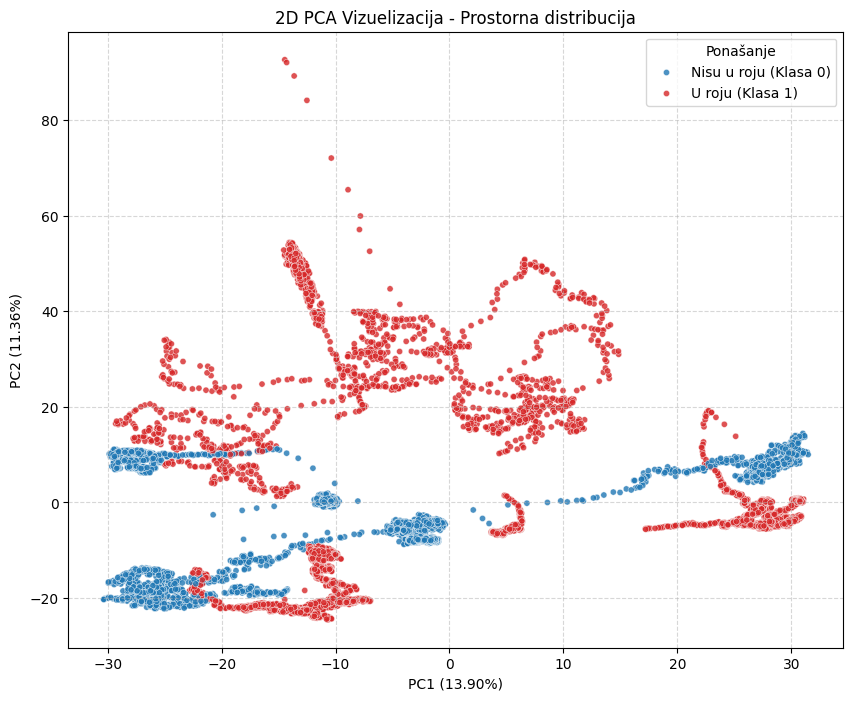

In [13]:
pca = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA redukcija završena. Broj kolona: {X_train_pca.shape[1]}")

plt.figure(figsize=(10, 8))

ax = sns.scatterplot(
    x=X_train_pca[:, 0], y=X_train_pca[:, 1],
    hue=y_train.values,
    palette=['#1f77b4', '#d62728'],
    alpha=0.8, s=20
)

plt.title('2D PCA Vizuelizacija - Prostorna distribucija')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Nisu u roju (Klasa 0)', 'U roju (Klasa 1)'], title='Ponašanje', loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


--- REZULTATI NA PCA SKUPU (90% VARIJANSE) ---
[Logistic Regression] Accuracy: 1.0000 | Vreme: 0.14s
[K-Nearest Neighbors] Accuracy: 1.0000 | Vreme: 2.15s
[SVM] Accuracy: 0.9983 | Vreme: 30.83s
[Random Forest] Accuracy: 1.0000 | Vreme: 22.24s
[LightGBM] Accuracy: 0.9994 | Vreme: 1.64s

--- REZULTATI NA RAZLIČITIM PCA SKUPOVIMA ---

>> Testiranje sa PCA = 3 komponenti <<
[Logistic Regression] Acc: 0.8289 | F1: 0.8275 | Rec: 0.8213 | Prec: 0.8338 | Vreme: 0.013s
[K-Nearest Neighbors] Acc: 1.0000 | F1: 1.0000 | Rec: 1.0000 | Prec: 1.0000 | Vreme: 0.019s
[SVM] Acc: 0.9898 | F1: 0.9898 | Rec: 0.9879 | Prec: 0.9916 | Vreme: 3.122s
[Random Forest] Acc: 0.9998 | F1: 0.9998 | Rec: 1.0000 | Prec: 0.9996 | Vreme: 0.881s
[LightGBM] Acc: 1.0000 | F1: 1.0000 | Rec: 1.0000 | Prec: 1.0000 | Vreme: 0.084s

>> Testiranje sa PCA = 5 komponenti <<
[Logistic Regression] Acc: 0.8257 | F1: 0.8237 | Rec: 0.8142 | Prec: 0.8333 | Vreme: 0.028s
[K-Nearest Neighbors] Acc: 1.0000 | F1: 1.0000 | Rec: 1.0000 | Prec

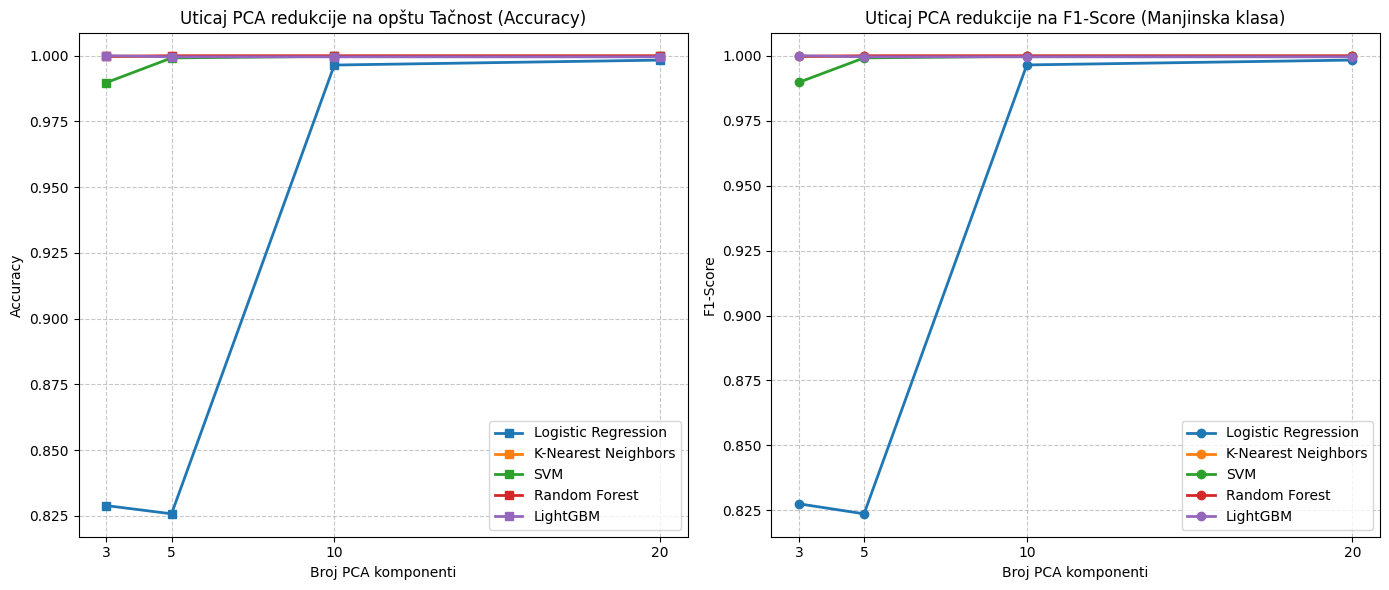

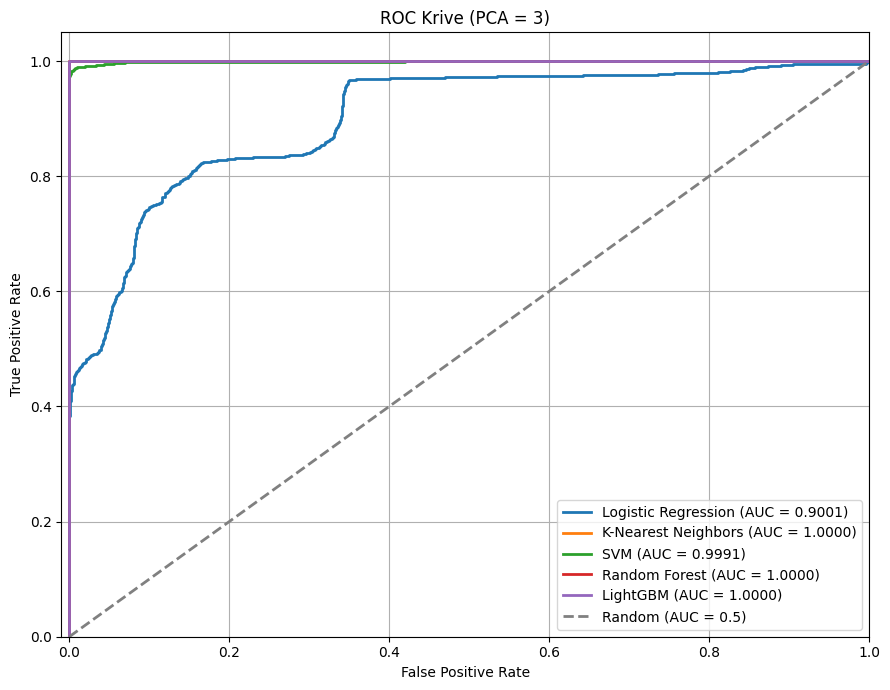

In [14]:
print("\n--- REZULTATI NA PCA SKUPU (90% VARIJANSE) ---")
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    end_time = time.time()
    acc = accuracy_score(y_test, y_pred)
    print(f"[{name}] Accuracy: {acc:.4f} | Vreme: {end_time - start_time:.2f}s")

print("\n--- REZULTATI NA RAZLIČITIM PCA SKUPOVIMA ---")
pca_accuracy_results = {name: [] for name in models.keys()}
pca_f1_results = {name: [] for name in models.keys()}
pca_num_list = [3, 5, 10, 20]

for n_comp in pca_num_list:
    print(f"\n>> Testiranje sa PCA = {n_comp} komponenti <<")
    pca_temp = PCA(n_components=n_comp, random_state=42)
    start_pca_time = time.time()
    X_train_pca_temp = pca_temp.fit_transform(X_train_scaled)
    X_test_pca_temp = pca_temp.transform(X_test_scaled)
    
    for name, model in models.items():
        start_time = time.time()
        model.fit(X_train_pca_temp, y_train)
        y_pred = model.predict(X_test_pca_temp)
        end_time = time.time()
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        pca_accuracy_results[name].append(acc)
        pca_f1_results[name].append(f1) 
        
        print(f"[{name}] Acc: {acc:.4f} | F1: {f1:.4f} | Rec: {rec:.4f} | Prec: {prec:.4f} | Vreme: {end_time - start_time:.3f}s")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, acc_list in pca_accuracy_results.items():
    axes[0].plot(pca_num_list, acc_list, marker='s', linewidth=2, label=name)
axes[0].set_title('Uticaj PCA redukcije na opštu Tačnost (Accuracy)')
axes[0].set_xlabel('Broj PCA komponenti')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(pca_num_list)
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.7)

for name, f1_list in pca_f1_results.items():
    axes[1].plot(pca_num_list, f1_list, marker='o', linewidth=2, label=name)
axes[1].set_title('Uticaj PCA redukcije na F1-Score (Manjinska klasa)')
axes[1].set_xlabel('Broj PCA komponenti')
axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(pca_num_list)
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))

pca_viz = PCA(n_components=3, random_state=42)
X_train_viz = pca_viz.fit_transform(X_train_scaled)
X_test_viz = pca_viz.transform(X_test_scaled)

for name, model in models.items():
    model.fit(X_train_viz, y_train)
    y_proba = model.predict_proba(X_test_viz)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random (AUC = 0.5)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Krive (PCA = 3)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


--- POREĐENJE METRIKA NA SVIM ATRIBUTIMA ---
[Logistic Regression] Acc: 1.0000 | F1: 1.0000 | Rec: 1.0000 | Prec: 1.0000 | Vreme: 0.73s
[K-Nearest Neighbors] Acc: 0.9998 | F1: 0.9998 | Rec: 0.9996 | Prec: 1.0000 | Vreme: 2.89s
[SVM] Acc: 0.9983 | F1: 0.9983 | Rec: 1.0000 | Prec: 0.9967 | Vreme: 219.72s
[Random Forest] Acc: 1.0000 | F1: 1.0000 | Rec: 1.0000 | Prec: 1.0000 | Vreme: 20.84s
[LightGBM] Acc: 1.0000 | F1: 1.0000 | Rec: 1.0000 | Prec: 1.0000 | Vreme: 9.57s


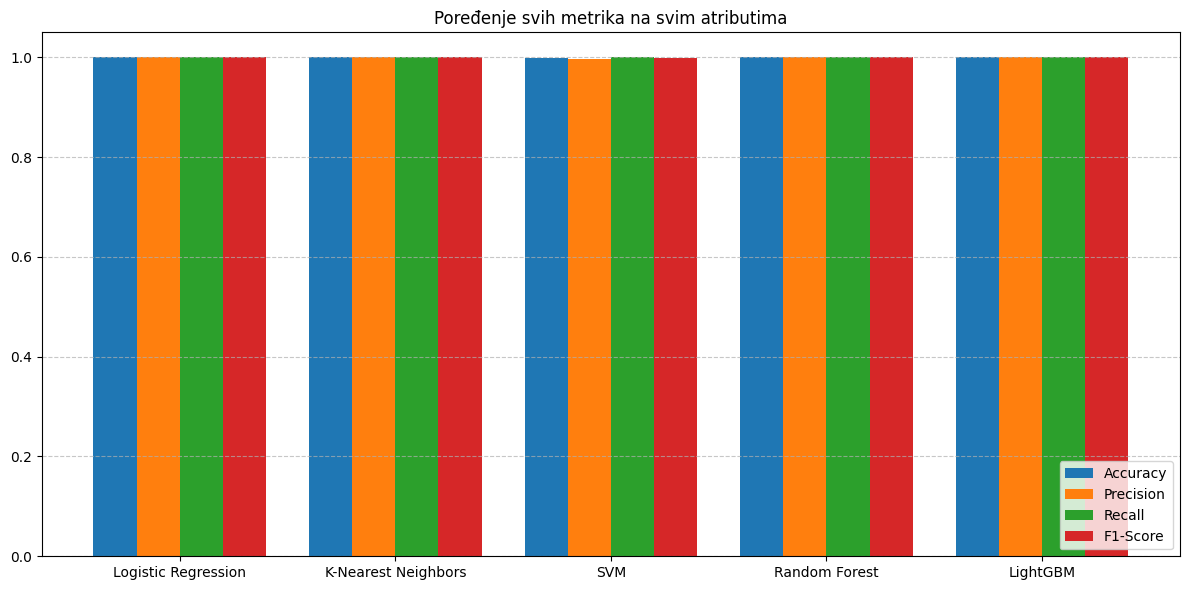

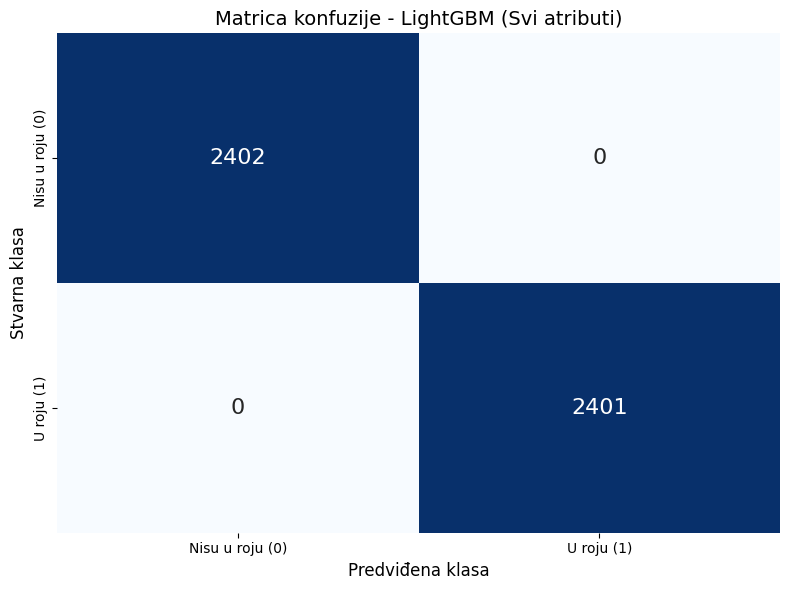

In [15]:
print("\n--- POREĐENJE METRIKA NA SVIM ATRIBUTIMA ---")
m_names, accs, precs, recs, f1s = [], [], [], [], []

for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    m_names.append(name)
    accs.append(acc)
    precs.append(prec)
    recs.append(rec)
    f1s.append(f1)
    
    print(f"[{name}] Acc: {acc:.4f} | F1: {f1:.4f} | Rec: {rec:.4f} | Prec: {prec:.4f} | Vreme: {time.time()-start:.2f}s")

x = np.arange(len(m_names))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, accs, width, label='Accuracy')
ax.bar(x - 0.5*width, precs, width, label='Precision')
ax.bar(x + 0.5*width, recs, width, label='Recall')
ax.bar(x + 1.5*width, f1s, width, label='F1-Score')

ax.set_xticks(x)
ax.set_xticklabels(m_names)
ax.set_title('Poređenje svih metrika na svim atributima')
ax.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

best_model = models["LightGBM"]
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Nisu u roju (0)', 'U roju (1)'], 
            yticklabels=['Nisu u roju (0)', 'U roju (1)'],
            annot_kws={"size": 16})
plt.title('Matrica konfuzije - LightGBM (Svi atributi)', fontsize=14)
plt.xlabel('Predviđena klasa', fontsize=12)
plt.ylabel('Stvarna klasa', fontsize=12)
plt.tight_layout()
plt.show()